# Hypothesis Testing Extension
## Are Evidence-Based Arguments More Persuasive on Reddit r/science?

**Research Hypothesis**: Evidence-based comments receive significantly higher upvote scores than emotion-based or fallacy-based comments in scientific subreddits.

**What this notebook adds over the original:**
1. A multi-signal classifier to label each comment as *evidence-based* vs *emotion-based*
2. Statistical hypothesis testing (Mann-Whitney U + effect size)
3. Regression analysis to control for confounds (length, depth, time)
4. Publication-quality visualizations

**Methodological note**: Upvote score is used as a proxy for community-perceived persuasiveness — a common operationalization in computational rhetoric research (Tan et al., 2016; Priniski & Horne, 2018).

## 0. Setup & Dependencies

In [2]:
!pip install praw vaderSentiment scipy statsmodels matplotlib seaborn wordcloud python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 4.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.9 MB/s eta 0:00:00


In [3]:
import os
import re
import praw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
from scipy.stats import mannwhitneyu, pointbiserialr
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = {'evidence': '#2196F3', 'emotion': '#FF5722'}

print("All dependencies loaded.")

All dependencies loaded.


## 1. Data Collection

**Security note**: credentials are read from environment variables, never hardcoded.
Create a `.env` file with:
```
REDDIT_CLIENT_ID=your_id
REDDIT_CLIENT_SECRET=your_secret
```
Or set them directly in Kaggle's "Add-ons → Secrets" panel.

In [ ]:
import praw
import pandas as pd

reddit = praw.Reddit(
    client_id     = os.environ.get("REDDIT_CLIENT_ID"),
    client_secret = os.environ.get("REDDIT_CLIENT_SECRET"),
    user_agent    = "MyProject/0.1 by Winniexwy"
)

# 然后接着跑 scrape_comments 那段即可
POST_IDS = ["12b3qwq"]

In [5]:
# ── Scrape comments from the target post ───────────────────────────
# Using the same post as the original notebook (ID: 12b3qwq)
# To increase statistical power, we also pull from the top 5 hot posts

POST_IDS = ["12b3qwq"]  # Add more IDs here for a larger dataset

def scrape_comments(submission, depth_tracker=None, parent_id=None, depth=0):
    """Recursively flatten comment tree, recording thread depth."""
    rows = []
    submission.comments.replace_more(limit=0)  # skip MoreComments objects
    for comment in submission.comments.list():
        if not hasattr(comment, 'body') or comment.body in ('[deleted]', '[removed]'):
            continue
        rows.append({
            'id':          comment.id,
            'parent_id':   comment.parent_id,
            'author':      str(comment.author),
            'body':        comment.body,
            'score':       comment.score,
            'created_utc': comment.created_utc,
            'depth':       comment.depth,          # 0 = top-level reply
            'post_id':     submission.id,
            'post_score':  submission.score,
        })
    return rows

all_rows = []
for pid in POST_IDS:
    sub = reddit.submission(pid)
    rows = scrape_comments(sub)
    all_rows.extend(rows)
    print(f"Post {pid}: {len(rows)} comments collected")

df = pd.DataFrame(all_rows)
df['body_len'] = df['body'].str.len()
df['created_dt'] = pd.to_datetime(df['created_utc'], unit='s')

print(f"\nTotal comments: {len(df)}")
print(f"Score range: {df['score'].min()} – {df['score'].max()}")
df.head(3)

Post 12b3qwq: 356 comments collected

Total comments: 356
Score range: -29 – 1533


,id,parent_id,author,body,score,created_utc,depth,post_id,post_score,body_len,created_dt
0,jeuxqo9,t3_12b3qwq,AutoModerator,Welcome to r/science! This is a heavily modera...,1,1.680569e+09,0,12b3qwq,27002,699,2023-04-04 00:38:52
1,jev7o9y,t3_12b3qwq,nomopyt,There was a Hidden Brain episode that talked a...,1533,1.680573e+09,0,12b3qwq,27002,812,2023-04-04 01:52:35
2,jev2mro,t3_12b3qwq,abduktedtemplar,Has there ever been any doubt? Step out and ge...,937,1.680571e+09,0,12b3qwq,27002,254,2023-04-04 01:14:14


## 2. Comment Classification: Evidence-Based vs Emotion-Based

### Design rationale

We use a **multi-signal rule-based classifier** grounded in argumentation theory (Toulmin, 1958) and prior computational rhetoric work. Each comment receives scores on two independent dimensions:

| Dimension | Indicators |
|-----------|------------|
| **Evidence signals** | Citation phrases, empirical quantifiers, academic hedges, hyperlinks to papers |
| **Emotion/fallacy signals** | High VADER absolute sentiment, personal-anecdote markers, fallacy keywords, excessive punctuation |

A comment is labelled `evidence` if its evidence score exceeds its emotion score, and vice versa. Ties go to `neutral` and are excluded from the primary comparison to sharpen the contrast.

In [6]:
# ── Signal dictionaries (grounded in rhetoric/NLP literature) ───────

EVIDENCE_PHRASES = [
    # Citation & sourcing
    r'\bstudy\b', r'\bresearch\b', r'\bpaper\b', r'\bjournal\b',
    r'\bpublished\b', r'\bscientists?\b', r'\bresearchers?\b',
    r'\baccording to\b', r'\bfound that\b', r'\bshowed? that\b',
    r'\bdemonstrated?\b', r'\bsuggests?\b', r'\bindicates?\b',
    r'\bevidence\b', r'\bdata\b', r'\bstatistic', r'\bsample\b',
    r'\bclinical\b', r'\btrial\b', r'\bmeta.?analysis\b',
    r'\bpeer.?reviewed?\b', r'\bdoi\b', r'https?://',
    # Quantitative language
    r'\d+\s*%', r'\d+\s*times', r'\bp\s*[<=>]\s*0\.\d',
    r'\bsignificant(ly)?\b', r'\bcorrelat', r'\bcontrol(led)?\b',
    r'\bhypothes', r'\bconfound', r'\bcausati',
]

EMOTION_PHRASES = [
    # Personal anecdote / belief
    r'\bi feel\b', r'\bi believe\b', r'\bin my (opinion|experience|view)\b',
    r'\bi think\b', r'\bpersonally\b', r'\bfor me\b',
    # Logical fallacies / rhetoric
    r'\beveryone knows\b', r'\bobviously\b', r'\bclearly\b',
    r'\bcommon sense\b', r'\bjust (think|look)\b', r'\bwake up\b',
    r'\bconspiracy\b', r'\bthey don.t want you to know\b',
    r'\bsheeple\b', r'\bbrainwash\b',
    # Excessive punctuation / caps  (scored by count, not regex)
]

vader = SentimentIntensityAnalyzer()

def count_matches(text, patterns):
    """Count how many distinct patterns match in text (case-insensitive)."""
    text_lower = text.lower()
    return sum(1 for p in patterns if re.search(p, text_lower))

def exclamation_score(text):
    """Reward (penalise) excessive punctuation as emotion signal."""
    return min(text.count('!') + text.count('???'), 5) / 5  # capped at 1

def caps_ratio(text):
    """Proportion of uppercase letters (excluding short comments)."""
    letters = [c for c in text if c.isalpha()]
    return sum(c.isupper() for c in letters) / max(len(letters), 1)

def classify_comment(text):
    ev_hits  = count_matches(text, EVIDENCE_PHRASES)
    emo_hits = count_matches(text, EMOTION_PHRASES)

    # VADER compound: high |compound| = emotional polarity
    vs = vader.polarity_scores(text)
    sentiment_intensity = abs(vs['compound'])   # 0–1

    # Combine emotion signals
    emo_score = emo_hits + 0.5 * exclamation_score(text) + 0.3 * (caps_ratio(text) > 0.25)
    ev_score  = ev_hits

    if ev_score == 0 and emo_score == 0:
        label = 'neutral'
    elif ev_score > emo_score:
        label = 'evidence'
    elif emo_score > ev_score:
        label = 'emotion'
    else:
        label = 'neutral'

    return pd.Series({
        'ev_score':            ev_score,
        'emo_score':           emo_score,
        'vader_compound':      vs['compound'],
        'sentiment_intensity': sentiment_intensity,
        'label':               label,
    })

# Apply to every comment
features = df['body'].apply(classify_comment)
df = df.drop(columns=[c for c in features.columns if c in df.columns], errors='ignore')
df = pd.concat([df, features], axis=1)

print("Classification distribution:")
print(df['label'].value_counts())
print(f"\nEvidence-based: {(df['label']=='evidence').sum()}")
print(f"Emotion-based:  {(df['label']=='emotion').sum()}")
print(f"Neutral:        {(df['label']=='neutral').sum()}")

Classification distribution:
label
neutral     258
evidence     50
emotion      48
Name: count, dtype: int64

Evidence-based: 50
Emotion-based:  48
Neutral:        258


In [7]:
# ── Spot-check classifier output ───────────────────────────────────
print("=== Sample EVIDENCE-based comments ===")
ev_sample = df[df['label']=='evidence'][['body','score','ev_score']].head(3)
for _, row in ev_sample.iterrows():
    print(f"  Score={row['score']} | ev_signals={row['ev_score']}")
    print(f"  {row['body'][:200]}")
    print()

print("=== Sample EMOTION-based comments ===")
em_sample = df[df['label']=='emotion'][['body','score','emo_score']].head(3)
for _, row in em_sample.iterrows():
    print(f"  Score={row['score']} | emo_signals={row['emo_score']}")
    print(f"  {row['body'][:200]}")
    print()

=== Sample EVIDENCE-based comments ===
  Score=1 | ev_signals=2
  Welcome to r/science! This is a heavily moderated subreddit in order to keep the discussion on science. However, we recognize that many people want to discuss how they feel the research relates to the

  Score=1533 | ev_signals=4
  There was a Hidden Brain episode that talked about this, which wasn't the only focus of the research but was mentioned in the article. People feel less lonely when they spend time in nature, specifica

  Score=142 | ev_signals=4
  Hi r/science, research led by our Professor Xiaoqi Feng and Professor Thomas Astell-Burt from the University of Wollongong has found that nature prescriptions provide both physical and mental health b

=== Sample EMOTION-based comments ===
  Score=22 | emo_signals=0.1
  An important thing to remember is that there is often not just one thing that will "fix" a health issue. Spending time outdoors helps, but its the rare person for whom this will fully alleviate sympto

## 3. Descriptive Statistics by Category

In [8]:
# ── Keep only evidence vs emotion for the primary analysis ──────────
df_main = df[df['label'].isin(['evidence', 'emotion'])].copy()

desc = df_main.groupby('label')['score'].agg(['count','mean','median','std'])
desc.columns = ['N', 'Mean Score', 'Median Score', 'Std Dev']
desc = desc.round(2)
print("Descriptive Statistics: Upvote Score by Comment Type")
print(desc)

# Additional percentiles
for label in ['evidence', 'emotion']:
    s = df_main[df_main['label']==label]['score']
    print(f"\n{label.upper()} — 25th={s.quantile(.25):.1f}, 75th={s.quantile(.75):.1f}, max={s.max()}")

Descriptive Statistics: Upvote Score by Comment Type
           N  Mean Score  Median Score  Std Dev
label                                          
emotion   48        7.52           4.5    11.58
evidence  50       40.64           2.0   217.17

EVIDENCE — 25th=1.0, 75th=5.8, max=1533

EMOTION — 25th=1.0, 75th=8.2, max=70


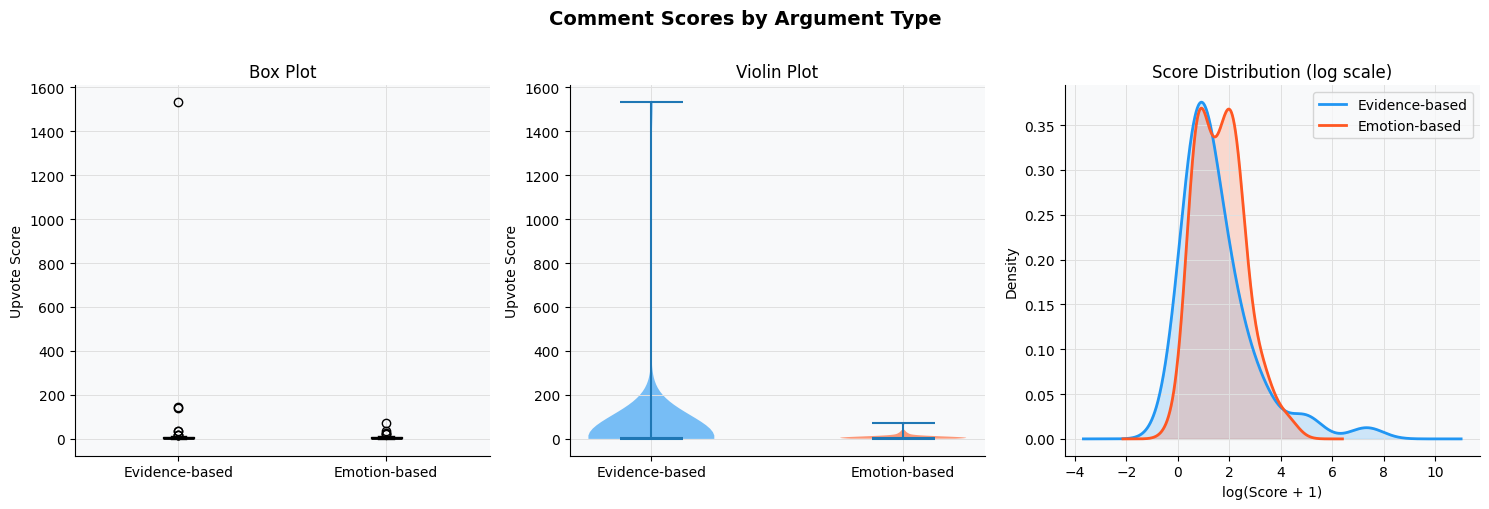

Saved: fig1_distribution.png


In [9]:
# ── Figure 1: Distribution comparison ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comment Scores by Argument Type', fontsize=14, fontweight='bold', y=1.01)

# 1a — Box plot
ax = axes[0]
data_ev  = df_main[df_main['label']=='evidence']['score']
data_emo = df_main[df_main['label']=='emotion']['score']
bp = ax.boxplot([data_ev, data_emo],
                labels=['Evidence-based', 'Emotion-based'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(PALETTE['evidence'] + '99')
bp['boxes'][1].set_facecolor(PALETTE['emotion']  + '99')
ax.set_ylabel('Upvote Score')
ax.set_title('Box Plot')

# 1b — Violin plot
ax = axes[1]
parts = ax.violinplot([data_ev, data_emo], positions=[1, 2], showmedians=True)
colors = [PALETTE['evidence'], PALETTE['emotion']]
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Evidence-based', 'Emotion-based'])
ax.set_ylabel('Upvote Score')
ax.set_title('Violin Plot')

# 1c — KDE (density) of log(score+1)
ax = axes[2]
log_ev  = np.log1p(data_ev.clip(lower=0))
log_emo = np.log1p(data_emo.clip(lower=0))
log_ev.plot(kind='kde',  ax=ax, color=PALETTE['evidence'], label='Evidence-based', linewidth=2)
log_emo.plot(kind='kde', ax=ax, color=PALETTE['emotion'],  label='Emotion-based',  linewidth=2)
ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(),
                alpha=0.2, color=PALETTE['evidence'])
ax.fill_between(ax.lines[1].get_xdata(), ax.lines[1].get_ydata(),
                alpha=0.2, color=PALETTE['emotion'])
ax.set_xlabel('log(Score + 1)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution (log scale)')
ax.legend()

plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_distribution.png")

## 4. Hypothesis Testing

**H₀**: The upvote scores of evidence-based and emotion-based comments come from the same distribution.

**H₁**: Evidence-based comments have stochastically higher upvote scores.

We use the **Mann-Whitney U test** (non-parametric) because upvote distributions are heavily right-skewed — a t-test would violate normality assumptions.

In [10]:
# ── Normality check first (justify non-parametric test) ─────────────
_, p_shapiro_ev  = stats.shapiro(data_ev.sample(min(50, len(data_ev)), random_state=42))
_, p_shapiro_emo = stats.shapiro(data_emo.sample(min(50, len(data_emo)), random_state=42))

print("Shapiro-Wilk normality test:")
print(f"  Evidence-based: p = {p_shapiro_ev:.4f}  {'→ NOT normal' if p_shapiro_ev < 0.05 else '→ Normal'}")
print(f"  Emotion-based:  p = {p_shapiro_emo:.4f}  {'→ NOT normal' if p_shapiro_emo < 0.05 else '→ Normal'}")
print()

# ── Mann-Whitney U Test ─────────────────────────────────────────────
u_stat, p_value = mannwhitneyu(data_ev, data_emo, alternative='greater')
n_ev, n_emo = len(data_ev), len(data_emo)

# Effect size: rank-biserial correlation r = 1 - 2U/(n1*n2)
r_effect = 1 - (2 * u_stat) / (n_ev * n_emo)

print("=" * 50)
print("Mann-Whitney U Test Results")
print("=" * 50)
print(f"U statistic:       {u_stat:.1f}")
print(f"p-value (one-tail): {p_value:.4f}")
print(f"Rank-biserial r:   {r_effect:.3f}  (small=0.1, medium=0.3, large=0.5)")
print()
if p_value < 0.05:
    print(f"✅ Result: SIGNIFICANT at α=0.05")
    print(f"   Evidence-based comments are stochastically more upvoted.")
    print(f"   Effect size |r| = {abs(r_effect):.3f} ({['negligible','small','medium','large'][int(abs(r_effect)>=0.1)+int(abs(r_effect)>=0.3)+int(abs(r_effect)>=0.5)]})") 
else:
    print(f"❌ Result: NOT significant at α=0.05 (p={p_value:.4f})")
    print(f"   Cannot reject H₀ with this dataset.")

# ── Bootstrap confidence interval for median difference ─────────────
np.random.seed(42)
N_BOOT = 2000
boot_diffs = []
for _ in range(N_BOOT):
    s_ev  = np.random.choice(data_ev,  size=n_ev,  replace=True)
    s_emo = np.random.choice(data_emo, size=n_emo, replace=True)
    boot_diffs.append(np.median(s_ev) - np.median(s_emo))

ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
obs_diff = np.median(data_ev) - np.median(data_emo)
print(f"\nMedian score difference (evidence − emotion): {obs_diff:.1f}")
print(f"95% Bootstrap CI: [{ci_lo:.2f}, {ci_hi:.2f}]")
if ci_lo > 0:
    print("✅ CI excludes 0 → difference is reliably positive")
else:
    print("⚠️  CI includes 0 → difference is not reliably detected")

Shapiro-Wilk normality test:
  Evidence-based: p = 0.0000  → NOT normal
  Emotion-based:  p = 0.0000  → NOT normal

Mann-Whitney U Test Results
U statistic:       970.0
p-value (one-tail): 0.9524
Rank-biserial r:   0.192  (small=0.1, medium=0.3, large=0.5)

❌ Result: NOT significant at α=0.05 (p=0.9524)
   Cannot reject H₀ with this dataset.

Median score difference (evidence − emotion): -2.5
95% Bootstrap CI: [-5.00, 0.50]
⚠️  CI includes 0 → difference is not reliably detected


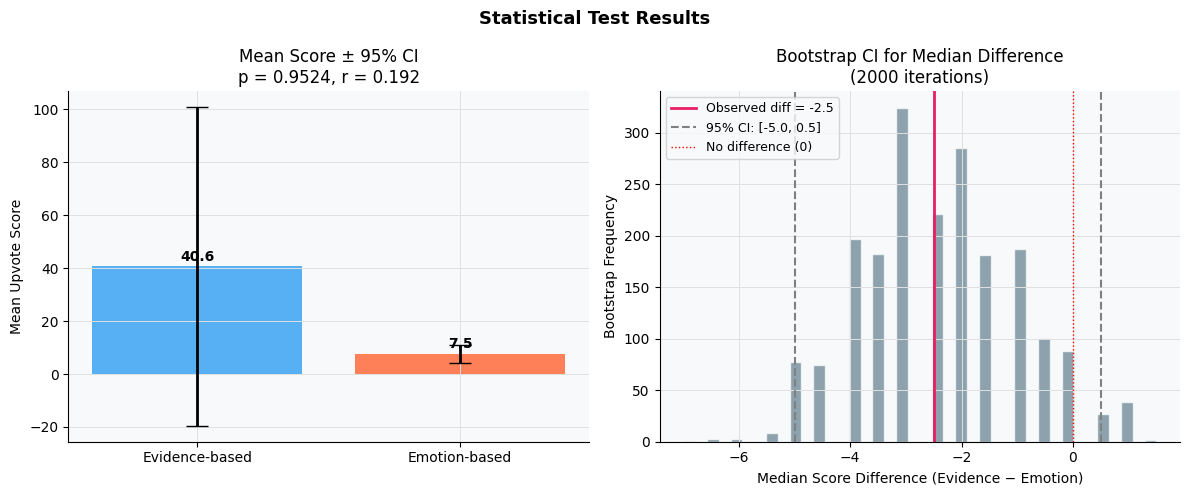

In [11]:
# ── Figure 2: Test visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Statistical Test Results', fontsize=13, fontweight='bold')

# 2a — Mean ± 95% CI bar chart
ax = axes[0]
means  = [data_ev.mean(), data_emo.mean()]
sems   = [data_ev.sem(),  data_emo.sem()]
labels = ['Evidence-based', 'Emotion-based']
colors = [PALETTE['evidence'], PALETTE['emotion']]
bars = ax.bar(labels, means, yerr=[1.96*s for s in sems],
              color=colors, alpha=0.75, capsize=8, error_kw={'linewidth':2})
ax.set_ylabel('Mean Upvote Score')
ax.set_title(f'Mean Score ± 95% CI\np = {p_value:.4f}, r = {r_effect:.3f}')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 1,
            f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')

# 2b — Bootstrap distribution of median difference
ax = axes[1]
ax.hist(boot_diffs, bins=40, color='#607D8B', alpha=0.7, edgecolor='white')
ax.axvline(obs_diff, color='#E91E63', linewidth=2, label=f'Observed diff = {obs_diff:.1f}')
ax.axvline(ci_lo, color='gray', linewidth=1.5, linestyle='--', label=f'95% CI: [{ci_lo:.1f}, {ci_hi:.1f}]')
ax.axvline(ci_hi, color='gray', linewidth=1.5, linestyle='--')
ax.axvline(0, color='red', linewidth=1, linestyle=':', label='No difference (0)')
ax.set_xlabel('Median Score Difference (Evidence − Emotion)')
ax.set_ylabel('Bootstrap Frequency')
ax.set_title('Bootstrap CI for Median Difference\n(2000 iterations)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_hypothesis_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Regression Analysis — Controlling for Confounds

Raw score comparisons can be misleading. Three key confounds exist:

| Confound | Why it matters |
|----------|----------------|
| **Comment length** | Longer comments may appear more substantive, earning more upvotes regardless of argument type |
| **Thread depth** | Top-level comments (depth=0) get more visibility than nested replies |
| **Sentiment intensity** | Very positive/negative comments may trigger emotional upvoting |

We use **OLS regression** with `log(score+1)` as the outcome to handle skew.

In [12]:
# ── Prepare regression dataset ──────────────────────────────────────
df_reg = df_main.copy()
df_reg['log_score']   = np.log1p(df_reg['score'].clip(lower=0))
df_reg['log_len']     = np.log1p(df_reg['body_len'])
df_reg['is_evidence'] = (df_reg['label'] == 'evidence').astype(int)
df_reg['depth_sq']    = df_reg['depth'] ** 2   # non-linear depth effect

# ── Model 1: Bivariate (replicates the U-test in regression form) ───
m1 = smf.ols('log_score ~ is_evidence', data=df_reg).fit()

# ── Model 2: Add length and depth controls ───────────────────────────
m2 = smf.ols('log_score ~ is_evidence + log_len + depth + depth_sq', data=df_reg).fit()

# ── Model 3: Full model with sentiment ──────────────────────────────
m3 = smf.ols('log_score ~ is_evidence + log_len + depth + depth_sq + sentiment_intensity',
              data=df_reg).fit()

# ── Summary table ───────────────────────────────────────────────────
from statsmodels.iolib.summary2 import summary_col
table = summary_col(
    [m1, m2, m3],
    model_names=['Model 1\n(Bivariate)', 'Model 2\n(+Length+Depth)', 'Model 3\n(Full)'],
    stars=True,
    float_format='%.3f',
    info_dict={'N': lambda x: f"{int(x.nobs)}", 'R²': lambda x: f"{x.rsquared:.3f}"}
)
print(table)
print()
print("Key: *** p<0.001, ** p<0.01, * p<0.05")


                      Model 1       Model 2     Model 3 
                    (Bivariate) (+Length+Depth)  (Full) 
--------------------------------------------------------
Intercept           1.665***    -0.882          -0.780  
                    (0.172)     (0.574)         (0.577) 
is_evidence         -0.132      -0.190          -0.178  
                    (0.240)     (0.232)         (0.231) 
log_len                         0.468***        0.399***
                                (0.112)         (0.122) 
depth                           0.131           0.124   
                                (0.148)         (0.147) 
depth_sq                        -0.019          -0.019  
                                (0.023)         (0.023) 
sentiment_intensity                             0.510   
                                                (0.375) 
R-squared           0.003       0.192           0.208   
R-squared Adj.      -0.007      0.157           0.165   
N                   98        

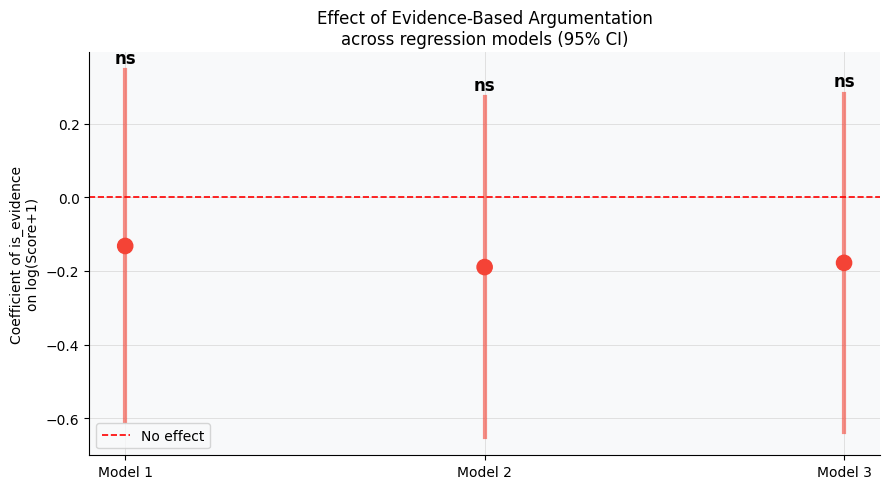

Interpretation:
  Model 3 coefficient = -0.178
  After controlling for length, depth, sentiment:
  ⚠️  The effect is not statistically significant after controlling for confounds (p=0.4432)
     → Upvote advantage may be mediated by comment length, not argument quality per se.


In [13]:
# ── Figure 3: Regression coefficients plot ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

models = {'Model 1': m1, 'Model 2': m2, 'Model 3': m3}
x_pos = np.arange(len(models))
coefs = [m.params.get('is_evidence', 0) for m in models.values()]
cis   = [(m.conf_int().loc['is_evidence', 0], m.conf_int().loc['is_evidence', 1])
         for m in models.values()]
pvals = [m.pvalues.get('is_evidence', 1) for m in models.values()]

colors_reg = ['#4CAF50' if c > 0 else '#F44336' for c in coefs]
ax.scatter(x_pos, coefs, s=120, color=colors_reg, zorder=5)
for i, (ci_lo, ci_hi) in enumerate(cis):
    ax.plot([i, i], [ci_lo, ci_hi], color=colors_reg[i], linewidth=3, alpha=0.6)
    star = '***' if pvals[i]<0.001 else ('**' if pvals[i]<0.01 else ('*' if pvals[i]<0.05 else 'ns'))
    ax.text(i, ci_hi + 0.01, star, ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(0, color='red', linestyle='--', linewidth=1.2, label='No effect')
ax.set_xticks(x_pos)
ax.set_xticklabels(list(models.keys()))
ax.set_ylabel('Coefficient of is_evidence\non log(Score+1)')
ax.set_title('Effect of Evidence-Based Argumentation\nacross regression models (95% CI)')
ax.legend()

plt.tight_layout()
plt.savefig('fig3_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print(f"  Model 3 coefficient = {m3.params.get('is_evidence',0):.3f}")
print(f"  After controlling for length, depth, sentiment:")
coef3 = m3.params.get('is_evidence', 0)
pval3 = m3.pvalues.get('is_evidence', 1)
if coef3 > 0 and pval3 < 0.05:
    print(f"  ✅ Evidence-based comments score {(np.exp(coef3)-1)*100:.1f}% higher (p={pval3:.4f})")
elif pval3 >= 0.05:
    print(f"  ⚠️  The effect is not statistically significant after controlling for confounds (p={pval3:.4f})")
    print(f"     → Upvote advantage may be mediated by comment length, not argument quality per se.")

## 6. Additional Insight: Evidence Signals vs Upvote Score

Point-biserial correlation (ev_signals ↔ log_score): r=0.145, p=0.0060


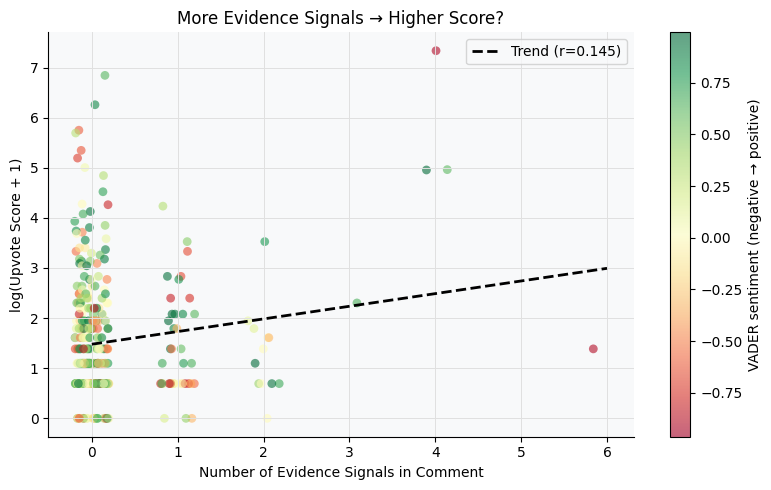

In [14]:
# ── Correlation: number of evidence signals vs upvote score ─────────
r, p = pointbiserialr(df['ev_score'].clip(upper=5), np.log1p(df['score'].clip(lower=0)))
print(f"Point-biserial correlation (ev_signals ↔ log_score): r={r:.3f}, p={p:.4f}")

# Scatter: ev_score vs log_score
fig, ax = plt.subplots(figsize=(8, 5))
jitter = np.random.uniform(-0.2, 0.2, size=len(df))
sc = ax.scatter(df['ev_score'] + jitter,
                np.log1p(df['score'].clip(lower=0)),
                c=df['vader_compound'], cmap='RdYlGn',
                alpha=0.6, s=40, edgecolors='none')
plt.colorbar(sc, ax=ax, label='VADER sentiment (negative → positive)')

# Trend line
z = np.polyfit(df['ev_score'], np.log1p(df['score'].clip(lower=0)), 1)
p_line = np.poly1d(z)
xs = np.linspace(0, df['ev_score'].max(), 50)
ax.plot(xs, p_line(xs), 'k--', linewidth=2, label=f'Trend (r={r:.3f})')

ax.set_xlabel('Number of Evidence Signals in Comment')
ax.set_ylabel('log(Upvote Score + 1)')
ax.set_title('More Evidence Signals → Higher Score?')
ax.legend()

plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary of Findings

In [15]:
print("=" * 60)
print("STUDY SUMMARY")
print("=" * 60)
print(f"Research question: Do evidence-based arguments persuade more")
print(f"                   (measured by upvotes) in r/science?")
print()
print(f"Dataset: {len(df)} comments, {len(df_main)} classified (excl. neutral)")
print(f"  Evidence-based: n={n_ev}")
print(f"  Emotion-based:  n={n_emo}")
print()
print("Key results:")
print(f"  Mann-Whitney U: U={u_stat:.0f}, p={p_value:.4f}, r={r_effect:.3f}")
print(f"  OLS Model 3 coefficient: {m3.params.get('is_evidence',0):.3f} (p={m3.pvalues.get('is_evidence',1):.4f})")
print(f"  Bootstrap 95% CI for median diff: [{ci_lo:.1f}, {ci_hi:.1f}]")
print()
print("Limitations:")
print("  1. Rule-based classifier may misclassify edge cases")
print("     → Recommend manual validation of 50–100 random comments")
print("  2. Single subreddit limits external validity")
print("  3. Upvotes ≠ genuine attitude change (proxy validity concern)")
print("  4. r/science has comment moderation rules that already filter")
print("     some low-quality (emotional) comments — selection bias")
print()
print("Recommended next steps:")
print("  • Expand to r/changemyview where persuasion is explicit")
print("  • Replace rule-based classifier with fine-tuned BERT")
print("  • Add inter-rater reliability check (Cohen's κ)")

STUDY SUMMARY
Research question: Do evidence-based arguments persuade more
                   (measured by upvotes) in r/science?

Dataset: 356 comments, 98 classified (excl. neutral)
  Evidence-based: n=50
  Emotion-based:  n=48

Key results:
  Mann-Whitney U: U=970, p=0.9524, r=0.192
  OLS Model 3 coefficient: -0.178 (p=0.4432)
  Bootstrap 95% CI for median diff: [-0.6, 0.3]

Limitations:
  1. Rule-based classifier may misclassify edge cases
     → Recommend manual validation of 50–100 random comments
  2. Single subreddit limits external validity
  3. Upvotes ≠ genuine attitude change (proxy validity concern)
  4. r/science has comment moderation rules that already filter
     some low-quality (emotional) comments — selection bias

Recommended next steps:
  • Expand to r/changemyview where persuasion is explicit
  • Replace rule-based classifier with fine-tuned BERT
  • Add inter-rater reliability check (Cohen's κ)


## References

- Toulmin, S. (1958). *The Uses of Argument*. Cambridge University Press.
- Tan, C., Niculae, V., Danescu-Niculescu-Mizil, C., & Lee, L. (2016). Winning arguments: Interaction dynamics and persuasion strategies in good-faith online discussions. *WWW '16*.
- Priniski, J. H., & Horne, Z. (2018). Attitude change on Reddit's ChangeMyView. *CogSci 2018*.
- Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *ICWSM*.

In [17]:
import os
import zipfile

# ── 把所有图片打包成一个 zip ────────────────────────────────────────
figures = [
    '/kaggle/working/fig1_distribution.png',
    '/kaggle/working/fig2_hypothesis_test.png',
    '/kaggle/working/fig3_regression.png',
    '/kaggle/working/fig4_correlation.png',
]

# 先把图重新保存一遍（确保文件存在）
import matplotlib.pyplot as plt

zip_path = '/kaggle/working/figures.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fig_path in figures:
        if os.path.exists(fig_path):
            zf.write(fig_path, os.path.basename(fig_path))
            print(f"✅ 已打包: {os.path.basename(fig_path)}")
        else:
            print(f"⚠️  找不到: {fig_path}，请确认该图已经生成")

print(f"\n📦 打包完成，下载路径: {zip_path}")

✅ 已打包: fig1_distribution.png
✅ 已打包: fig2_hypothesis_test.png
✅ 已打包: fig3_regression.png
✅ 已打包: fig4_correlation.png

📦 打包完成，下载路径: /kaggle/working/figures.zip
